In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, ResNet50V2, DenseNet121, EfficientNetB0
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score
)
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU disponible: {len(gpus)} dispositivo(s)")
    except RuntimeError as e:
        print(e)
else:
    print("Usando CPU")


Usando CPU


In [24]:
MODEL_NAME = "RESNET50"

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion", 
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass", "No Finding",
    "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"
]

NUM_CLASSES = len(LABEL_COLS)
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
THRESHOLD = 0.7
IMG_SIZE = (224, 224)

print(f"MODELO SELECCIONADO: {MODEL_NAME}")
print(f"Número de clases: {NUM_CLASSES}")
print(f"Tamaño de imagen: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Épocas: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

MODELO SELECCIONADO: RESNET50
Número de clases: 15
Tamaño de imagen: (224, 224)
Batch size: 16
Épocas: 10
Learning rate: 0.0001


In [4]:
class CustomDataGenerator(keras.utils.Sequence):
    
    def __init__(self, df, img_dir, batch_size=32, img_size=(224, 224), 
                 augment=False, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.label_cols = LABEL_COLS
        self.indexes = np.arange(len(self.df))
        
        # Data augmentation
        if self.augment:
            self.datagen = ImageDataGenerator(
                horizontal_flip=True,
                rotation_range=10,
                preprocessing_function=keras.applications.resnet50.preprocess_input
            )
        else:
            self.datagen = ImageDataGenerator(
                preprocessing_function=keras.applications.resnet50.preprocess_input
            )
        
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[indexes]
        
        X, y = self._generate_data(batch_df)
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def _generate_data(self, batch_df):
        X = np.empty((len(batch_df), *self.img_size, 3))
        y = np.empty((len(batch_df), NUM_CLASSES))
        
        for i, (idx, row) in enumerate(batch_df.iterrows()):
            img_path = os.path.join(self.img_dir, row['Image Index'])
            img = keras.preprocessing.image.load_img(img_path, target_size=self.img_size)
            img_array = keras.preprocessing.image.img_to_array(img)
            
            if self.augment:
                img_array = self.datagen.random_transform(img_array)
            
            X[i,] = img_array
            y[i,] = row[self.label_cols].values.astype(np.float32)
        
        X = keras.applications.resnet50.preprocess_input(X)
        
        return X, y

In [5]:

df = pd.read_csv("../Datasets/4/sample_labels_processed.csv")
df = df.drop(columns=['Finding Labels'], errors='ignore')

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

print(f"\nTamaño train: {len(train_df)}")
print(f"Tamaño test: {len(test_df)}")

IMG_DIR = "../Datasets/4/sample/images"

train_generator = CustomDataGenerator(
    train_df, IMG_DIR, 
    batch_size=BATCH_SIZE, 
    img_size=IMG_SIZE,
    augment=True, 
    shuffle=True
)

test_generator = CustomDataGenerator(
    test_df, IMG_DIR, 
    batch_size=BATCH_SIZE, 
    img_size=IMG_SIZE,
    augment=False, 
    shuffle=False
)

print(f"Batches de entrenamiento: {len(train_generator)}")
print(f"Batches de test: {len(test_generator)}")


Tamaño train: 4485
Tamaño test: 1121
Batches de entrenamiento: 281
Batches de test: 71


In [6]:
def create_model(model_name, num_classes=NUM_CLASSES):
    
    keras.backend.clear_session()
    
    if model_name == "RESNET50":
        base_model = ResNet50(weights='imagenet', include_top=False, 
                             input_shape=(*IMG_SIZE, 3))
    else:
        raise ValueError(f"Modelo {model_name} no soportado")
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print(f"Creando modelo: {MODEL_NAME}")

model = create_model(MODEL_NAME)
print(f"Parámetros totales: {model.count_params():,}")
print(f"Parámetros entrenables: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

model.summary()

Creando modelo: RESNET50

Parámetros totales: 23,618,447
Parámetros entrenables: 23,565,327


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 23,565,327 (89.89 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [7]:

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        f'best_{MODEL_NAME}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:

print(f"ENTRENANDO {MODEL_NAME}")

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    # callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("RESUMEN DE ENTRENAMIENTO")
print(f"Pérdida final (train): {train_loss:.4f}")
print(f"Pérdida final (val):   {val_loss:.4f}")
print(f"Accuracy final (train): {train_acc:.4f}")
print(f"Accuracy final (val):   {val_acc:.4f}")


ENTRENANDO RESNET50


d:\Ciclo VIII\Data-Mining-Tools\env311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4720 - loss: 0.2716

d:\Ciclo VIII\Data-Mining-Tools\env311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


281/281 ━━━━━━━━━━━━━━━━━━━━ 1095s 4s/step - accuracy: 0.5133 - loss: 0.2223 - val_accuracy: 0.5031 - val_loss: 0.2053
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1072s 4s/step - accuracy: 0.5436 - loss: 0.1937 - val_accuracy: 0.5263 - val_loss: 0.2076
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1053s 4s/step - accuracy: 0.5565 - loss: 0.1838 - val_accuracy: 0.5272 - val_loss: 0.2031
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1049s 4s/step - accuracy: 0.5732 - loss: 0.1739 - val_accuracy: 0.4817 - val_loss: 0.2097
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1056s 4s/step - accuracy: 0.5797 - loss: 0.1648 - val_accuracy: 0.5290 - val_loss: 0.1965
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1060s 4s/step - accuracy: 0.6114 - loss: 0.1525 - val_accuracy: 0.4710 - val_loss: 0.2184
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1097s 4s/step - accuracy: 0.6310 - loss: 0.1425 - val_accuracy: 0.5013 - val_loss: 0.2166
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1084s 4s/step - accuracy: 0.6669 - loss: 0.1289 - val_accurac

In [20]:
def evaluate_model(model, generator, class_names=None, threshold=THRESHOLD):
    
    print("EVALUACIÓN DETALLADA")
    print("Generando predicciones...")
    
    y_true = []
    y_pred = []
    
    for i in tqdm(range(len(generator)), desc="Evaluando"):
        X_batch, y_batch = generator[i]
        pred_batch = model.predict(X_batch, verbose=0)
        y_true.append(y_batch)
        y_pred.append(pred_batch)
    
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    
    aucs, accs, precisions, recalls, f1s = [], [], [], [], []
    num_classes = y_true.shape[1]
    
    for i in range(num_classes):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        except ValueError:
            auc = np.nan
        aucs.append(auc)
        
        y_pred_bin = (y_pred[:, i] >= threshold).astype(int)
        
        accs.append(accuracy_score(y_true[:, i], y_pred_bin))
        precisions.append(precision_score(y_true[:, i], y_pred_bin, zero_division=0))
        recalls.append(recall_score(y_true[:, i], y_pred_bin, zero_division=0))
        f1s.append(f1_score(y_true[:, i], y_pred_bin, zero_division=0))
    
    auc_mean = np.nanmean(aucs)
    acc_mean = np.mean(accs)
    prec_mean = np.mean(precisions)
    rec_mean = np.mean(recalls)
    f1_mean = np.mean(f1s)
    
    if class_names is None:
        class_names = [f'Clase_{i}' for i in range(num_classes)]
    
    metrics_df = pd.DataFrame({
        'Clase': class_names,
        'AUC': np.round(aucs, 4),
        'Accuracy': np.round(accs, 4),
        'Precision': np.round(precisions, 4),
        'Recall': np.round(recalls, 4),
        'F1-Score': np.round(f1s, 4)
    }).sort_values(by='AUC', ascending=False)
    
    print("RESULTADOS GLOBALES")
    print(f"AUC promedio:       {auc_mean:.4f}")
    print(f"Accuracy promedio:  {acc_mean:.4f}")
    print(f"Precision promedio: {prec_mean:.4f}")
    print(f"Recall promedio:    {rec_mean:.4f}")
    print(f"F1 promedio:        {f1_mean:.4f}")
    print(f"\nMétricas por clase (umbral = {threshold})")
    display(metrics_df)
    
    return auc_mean, acc_mean, prec_mean, rec_mean, f1_mean, metrics_df

In [21]:
auc_mean, acc_mean, prec_mean, rec_mean, f1_mean, metrics_df = evaluate_model(
    model, test_generator, class_names=LABEL_COLS, threshold=THRESHOLD
)

EVALUACIÓN DETALLADA
Generando predicciones...


Evaluando: 100%|██████████| 71/71 [01:32<00:00,  1.30s/it]


RESULTADOS GLOBALES
AUC promedio:       0.4969
Accuracy promedio:  0.5302
Precision promedio: 0.0769
Recall promedio:    0.4184
F1 promedio:        0.0575

Métricas por clase (umbral = 0.5)


,Clase,AUC,Accuracy,Precision,Recall,F1-Score
1,Cardiomegaly,0.6152,0.9652,0.0000,0.0000,0.0000
2,Consolidation,0.5735,0.9554,0.0000,0.0000,0.0000
11,Nodule,0.5685,0.6583,0.0871,0.4714,0.1470
8,Infiltration,0.5590,0.8109,0.1000,0.0049,0.0093
12,Pleural_Thickening,0.5560,0.2177,0.0310,0.9333,0.0600
0,Atelectasis,0.5363,0.1302,0.0807,0.9239,0.1485
14,Pneumothorax,0.5191,0.8573,0.0513,0.1091,0.0698
4,Effusion,0.5184,0.3800,0.1308,0.7279,0.2217
13,Pneumonia,0.5007,0.0259,0.0144,1.0000,0.0285
9,Mass,0.4953,0.2221,0.0519,0.7705,0.0973


In [ ]:

metrics_df.to_csv(f"metrics_{MODEL_NAME}.csv", index=False)
print(f"\nMétricas guardadas en 'metrics_{MODEL_NAME}.csv'")

model.save(f"model_{MODEL_NAME}.keras")
print(f"Modelo guardado en 'model_{MODEL_NAME}.keras'")

summary = {
    "Modelo": MODEL_NAME,
    "Epochs": EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Threshold": THRESHOLD,
    "Train Loss": train_loss,
    "Val Loss": val_loss,
    "Train Accuracy": train_acc,
    "Val Accuracy": val_acc,
    "AUC promedio": auc_mean,
    "Accuracy promedio": acc_mean,
    "Precision promedio": prec_mean,
    "Recall promedio": rec_mean,
    "F1 promedio": f1_mean
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"summary_{MODEL_NAME}.csv", index=False)
print(f"Resumen guardado en 'summary_{MODEL_NAME}.csv'")
print("PROCESO COMPLETADO")


Métricas guardadas en 'metrics_RESNET50.csv'
Modelo guardado en 'model_RESNET50.keras'
Resumen guardado en 'summary_RESNET50.csv'
PROCESO COMPLETADO


In [ ]:
loaded_model = keras.models.load_model(f"model_{MODEL_NAME}.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


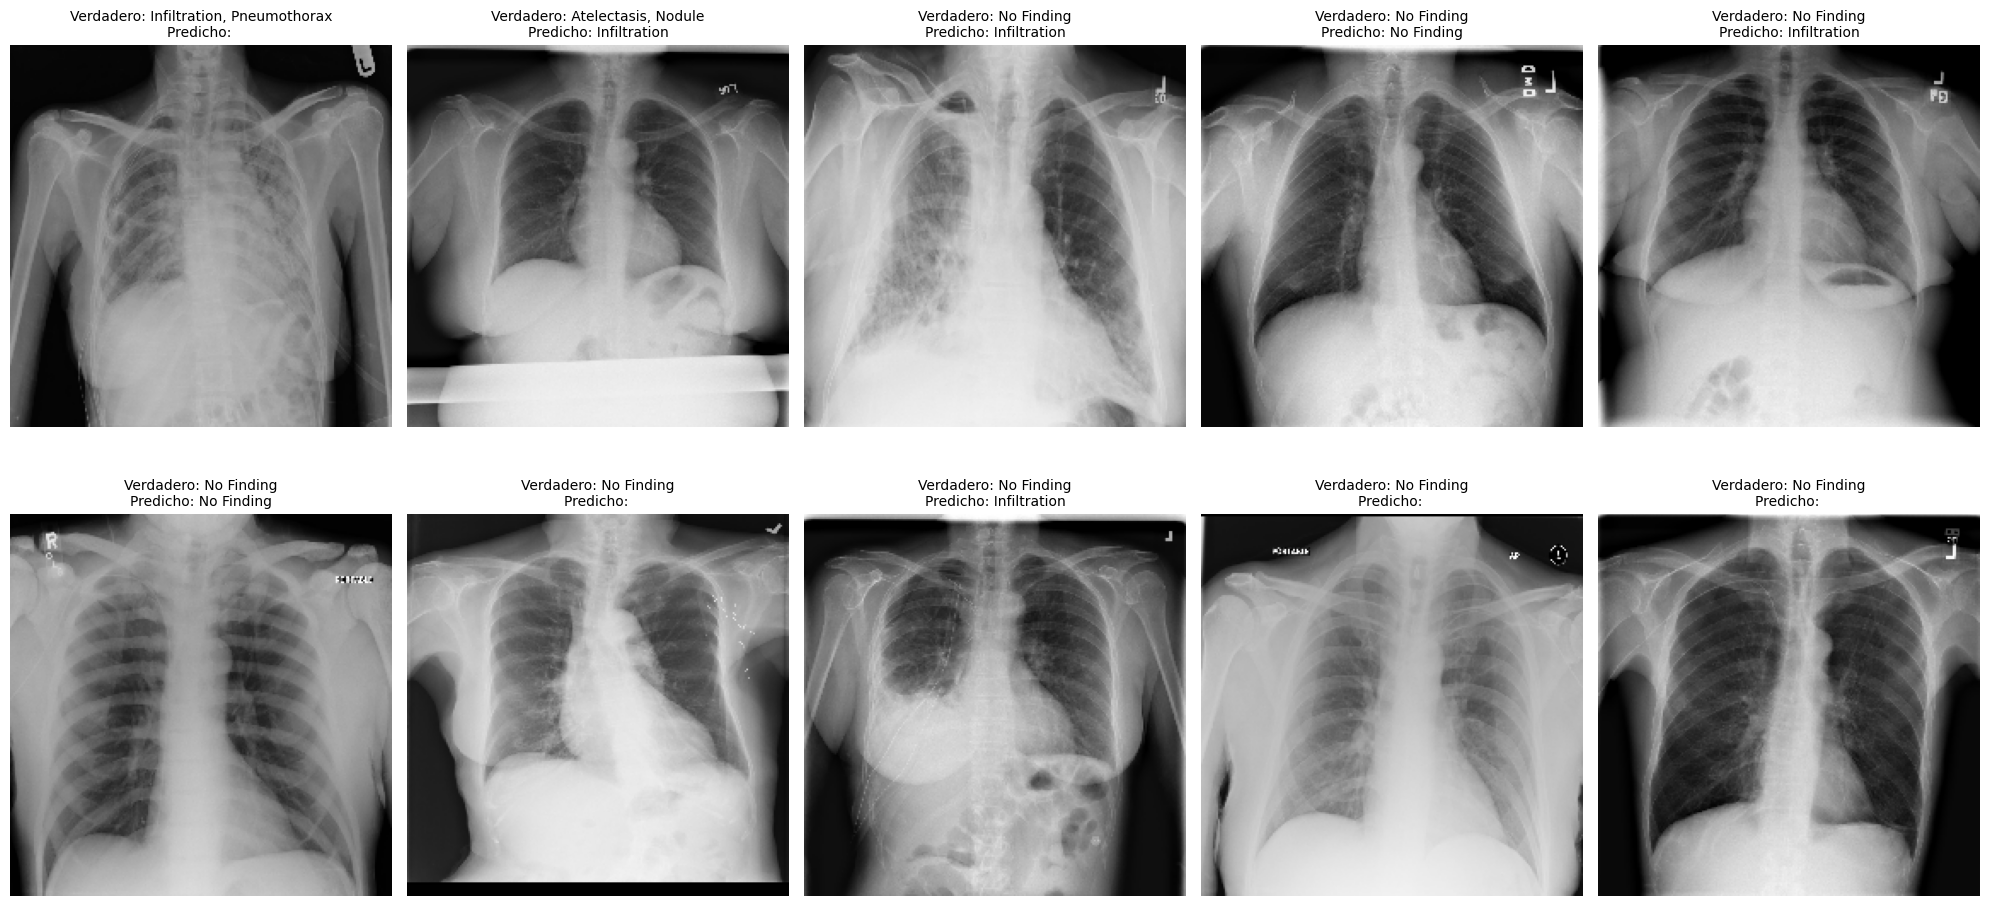

In [ ]:
sample_df = test_df.sample(n=10).reset_index(drop=True)

plt.figure(figsize=(20, 10))
for i, row in sample_df.iterrows():
    img_path = os.path.join(IMG_DIR, row['Image Index'])
    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = keras.applications.resnet50.preprocess_input(img_array)
    
    pred = loaded_model.predict(img_array)[0]
    pred_labels = [LABEL_COLS[j] for j, p in enumerate(pred) if p >= THRESHOLD]
    true_labels = [LABEL_COLS[j] for j, v in enumerate(row[LABEL_COLS].values) if v == 1]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {', '.join(true_labels)}\nPredicho: {', '.join(pred_labels)}", fontsize=10)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


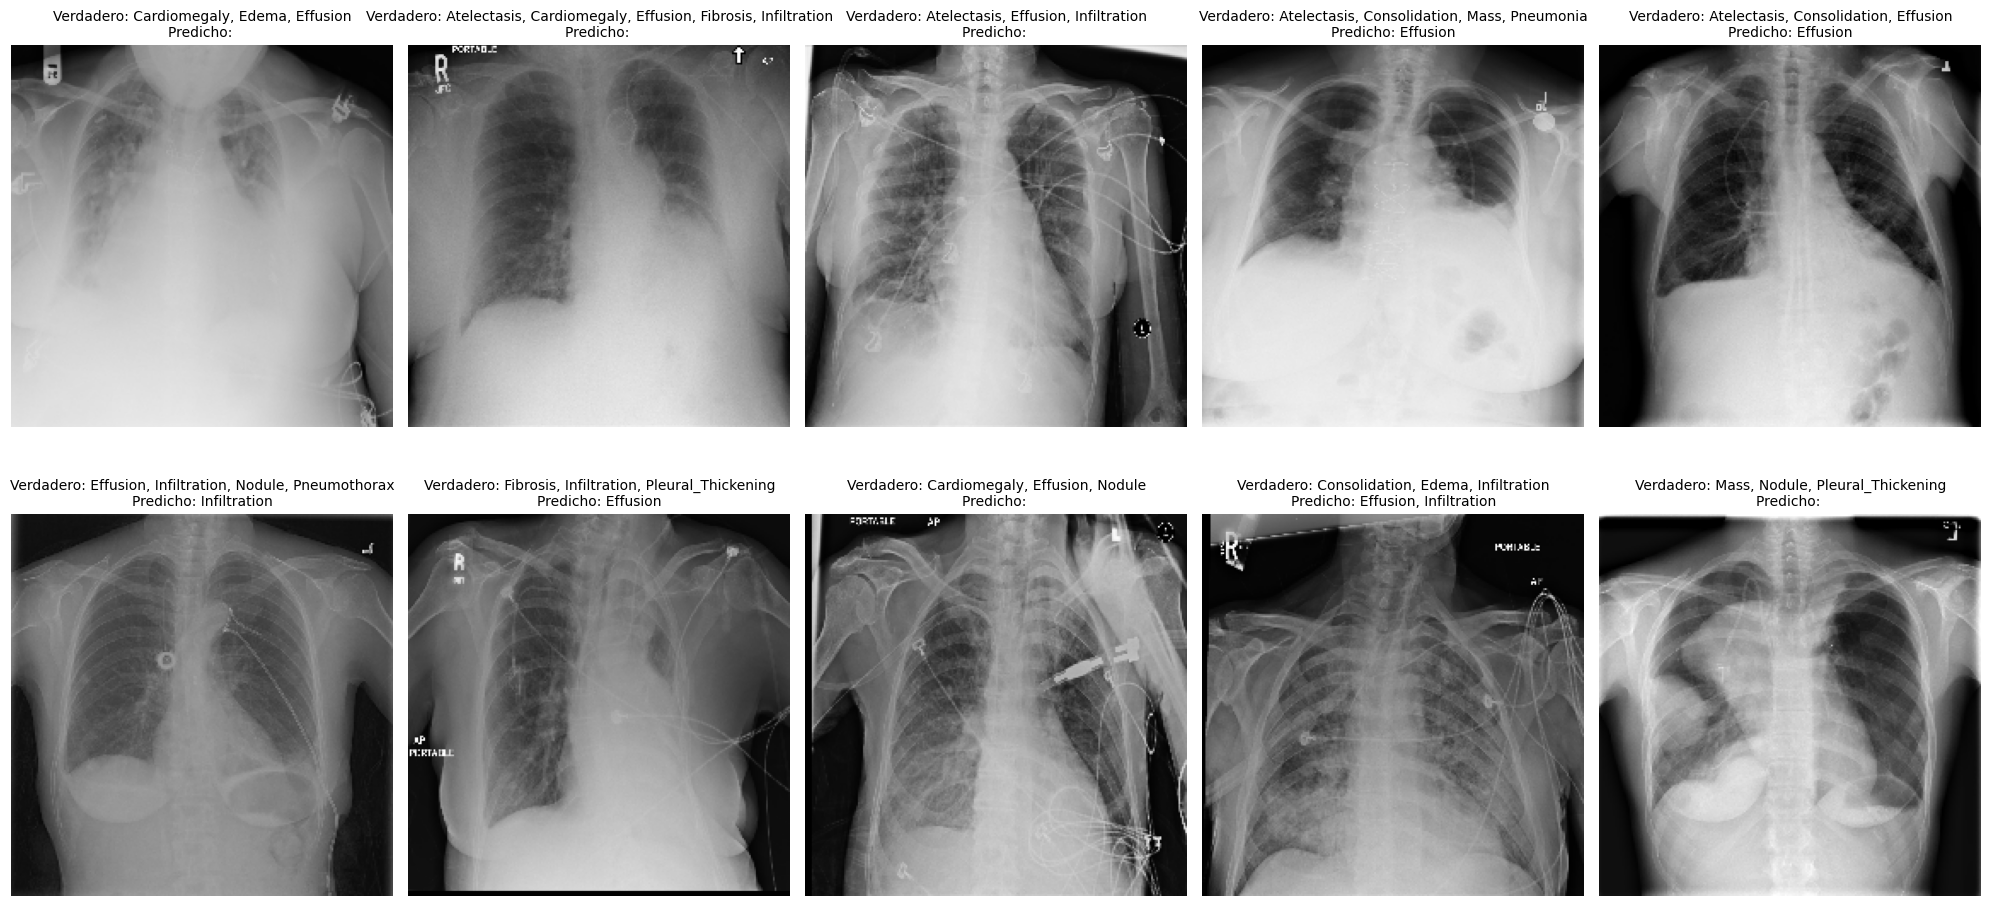

In [ ]:
multi_label_df = test_df[test_df[LABEL_COLS].sum(axis=1) > 2]

sample_df = multi_label_df.sample(n=min(10, len(multi_label_df)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(20, 10))
for i, row in sample_df.iterrows():
    img_path = os.path.join(IMG_DIR, row['Image Index'])
    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = keras.applications.resnet50.preprocess_input(img_array)
    
    pred = loaded_model.predict(img_array)[0]
    pred_labels = [LABEL_COLS[j] for j, p in enumerate(pred) if p >= THRESHOLD]
    true_labels = [LABEL_COLS[j] for j, v in enumerate(row[LABEL_COLS].values) if v == 1]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {', '.join(true_labels)}\nPredicho: {', '.join(pred_labels)}", fontsize=10)

plt.tight_layout()
plt.show()